In [10]:
!pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [contextily]4 [contextily]ib]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os

# Change to your directory
os.chdir('/Users/terezasaskova/Library/Mobile Documents/com~apple~CloudDocs/sentinel-2-based-prediction')



In [4]:

import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.colors import ListedColormap

# 1. Load Data
aoi = gpd.read_file('data/boundaries/sumava_np.geojson')
zones = gpd.read_file('data/boundaries/sumava_zones.geojson')



In [2]:

print("Unique ZONE values:", zones['ZONA'].unique())
print("\nValue counts:")
print(zones['ZONA'].value_counts())
print("\nColumn names:", zones.columns.tolist())
print("\nFirst few rows:")
print(zones[['ZONA']].head())

Unique ZONE values: <ArrowStringArray>
['A', 'B', 'C', 'D', 'I', 'II', 'III', 'IV']
Length: 8, dtype: str

Value counts:
ZONA
A      1
B      1
C      1
D      1
I      1
II     1
III    1
IV     1
Name: count, dtype: int64

Column names: ['OBJECTID', 'KOD', 'KAT', 'NAZEV', 'ZONA', 'ZMENA_G', 'ZMENA_T', 'PREKRYV', 'DBID', 'SHAPEAREA', 'SHAPELEN', 'geometry']

First few rows:
  ZONA
0    A
1    B
2    C
3    D
4    I


In [5]:
# 2. Reproject to Web Mercator (EPSG:3857) for OSM basemap
# Contextily requires this CRS to fetch tiles correctly
aoi_wgs = aoi.to_crs(epsg=4326) # Ensure original is WGS84 if needed
zones_wgs = zones.to_crs(epsg=4326)

# Filter for NP (National Park) only
zones_np = zones[zones['KAT'] == 'NP'].copy()

# Then use zones_np instead of zones for all subsequent operations
zones_wgs = zones_np.to_crs(epsg=4326)
zones_plot = zones_wgs.to_crs(epsg=3857)



Found 4 NP zones.


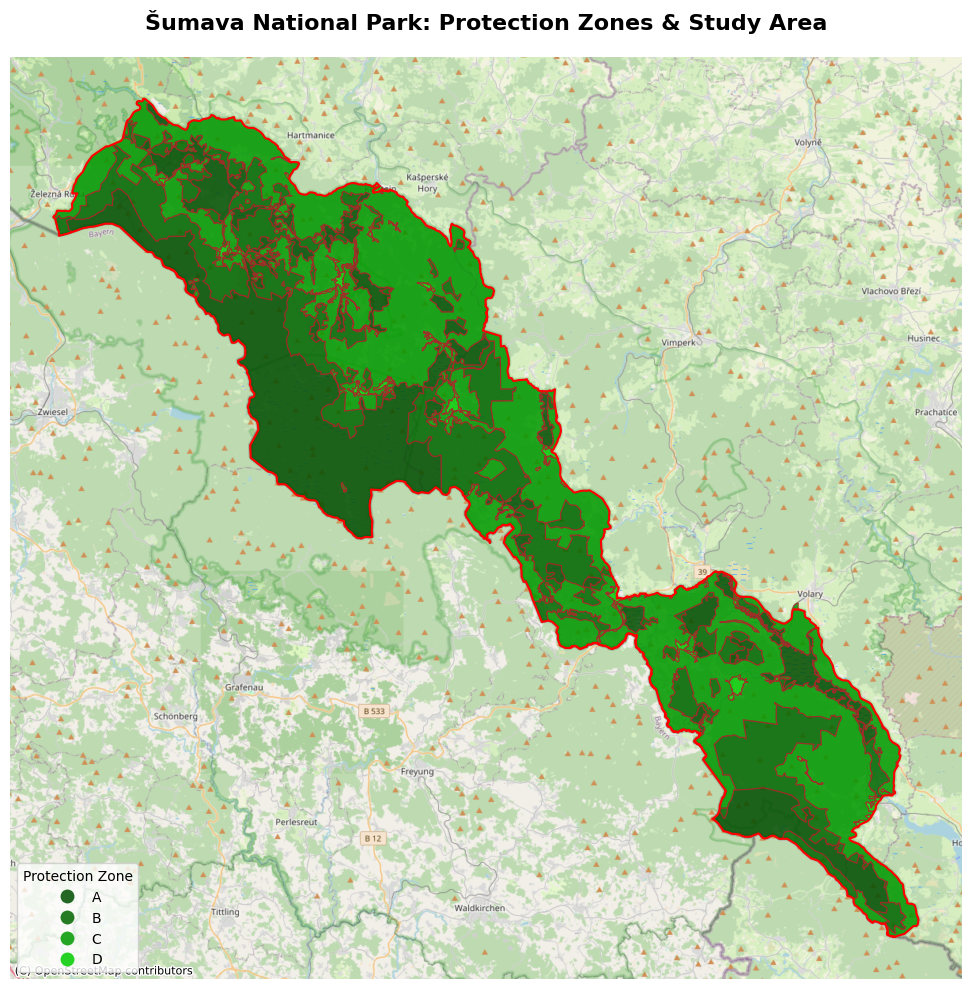

Saved to figures/sumava_visualization.png


In [ ]:
zones_np = zones[zones['KAT'] == 'NP'].copy()

if len(zones_np) == 0:
    print("Warning: No NP zones found in the dataset.")
else:
    print(f"Found {len(zones_np)} NP zones.")
    
    # Ensure zones are in WGS84 first
    zones_wgs = zones_np.to_crs(epsg=4326)
    zones_plot = zones_wgs.to_crs(epsg=3857)
    
    # Ensure AOI is also reprojected to match
    if 'aoi' in globals():
        aoi_wgs = aoi.to_crs(epsg=4326)
        aoi_plot = aoi_wgs.to_crs(epsg=3857)
    else:
        raise ValueError("Variable 'aoi' not found. Please define it before running this script.")

    fig, ax = plt.subplots(figsize=(12, 10))    
    zone_colors = ['#004d00', '#006600', '#009900', '#00cc00']
    categories_to_plot = ['A', 'B', 'C', 'D']
    
    # Filter zones_plot to only include these categories if necessary, 
    zones_to_plot = zones_plot[zones_plot['ZONA'].isin(categories_to_plot)]
    
    if len(zones_to_plot) > 0:
        cmap = ListedColormap(zone_colors)
        
        zones_to_plot.plot(
            ax=ax,
            column='ZONA',
            cmap=cmap,
            categorical=True,
            categories=categories_to_plot,
            legend=True,
            legend_kwds={
                'loc': 'lower left',
                'frameon': True,
                'fontsize': 10,
                'title': 'Protection Zone' # Fixed: use 'title' not 'label'
            },
            edgecolor='brown',
            linewidth=0.8,
            alpha=0.85
        )
        
        aoi_plot.boundary.plot(ax=ax, color='red', linewidth=1.5, label='AOI Boundary') # Changed to red as per your comment "Red outline"
        
        #Contextily works best when the axis is in EPSG:3857
        try:
            ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=11)
        except Exception as e:
            print(f"Basemap failed (likely no internet): {e}")
            ax.set_facecolor('#f0f0f0') # Fallback background

        ax.set_title('Šumava National Park: Protection Zones & Study Area', 
                     fontsize=16, fontweight='bold', pad=20)
        ax.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        save_path = 'figures/sumava_visualization.png'
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300)
        print(f"Saved to {save_path}")
    else:
        print("No matching zones (A, B, C, D) found after filtering.")